## 1. Import Required Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Generate Synthetic Training Data

We'll create realistic mushroom cultivation data based on optimal growing conditions for oyster mushrooms.

In [16]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 500 training samples
n_samples = 500

# Generate environmental features
# Optimal ranges for oyster mushrooms:
# Temperature: 20-25°C (optimal ~23°C)
# Humidity: 75-90% (optimal ~85%)
# CO2: 600-1200 ppm (optimal ~900 ppm)
# Growth duration: 25-40 days

temperature = np.random.normal(23, 2.5, n_samples)  # Mean 23°C, std 2.5
humidity = np.random.normal(85, 5, n_samples)       # Mean 85%, std 5
co2 = np.random.normal(900, 150, n_samples)         # Mean 900 ppm, std 150
growth_days = np.random.randint(25, 41, n_samples)  # 25-40 days

# Calculate yield based on how close conditions are to optimal
# Base yield: 3-5 kg
# Adjustments based on environmental conditions

base_yield = 4.0  # kg

# Temperature factor (optimal = 23°C)
temp_factor = 1 - (abs(temperature - 23) / 10) * 0.3

# Humidity factor (optimal = 85%)
hum_factor = 1 - (abs(humidity - 85) / 20) * 0.25

# CO2 factor (optimal = 900 ppm)
co2_factor = 1 - (abs(co2 - 900) / 400) * 0.2

# Growth duration factor (optimal = 32-35 days)
growth_factor = np.where(
    (growth_days >= 32) & (growth_days <= 35),
    1.1,  # Bonus for optimal duration
    1 - (abs(growth_days - 33.5) / 20) * 0.15
)

# Calculate yield with some random noise
yield_kg = (base_yield * temp_factor * hum_factor * co2_factor * growth_factor + 
            np.random.normal(0, 0.2, n_samples))

# Ensure yield is positive and realistic (0.5 - 6 kg)
yield_kg = np.clip(yield_kg, 0.5, 6.0)

# Create DataFrame
data = pd.DataFrame({
    'temperature': np.round(temperature, 1),
    'humidity': np.round(humidity, 1),
    'co2_ppm': np.round(co2, 0).astype(int),
    'growth_days': growth_days,
    'yield_kg': np.round(yield_kg, 2)
})

print(f"Generated {len(data)} training samples")
print("\nFirst 5 rows:")
data.head()

Generated 500 training samples

First 5 rows:


,temperature,humidity,co2_ppm,growth_days,yield_kg
0,24.2,89.6,1110,39,3.18
1,22.7,94.5,1039,36,3.28
2,24.6,78.0,909,36,3.52
3,26.8,87.8,803,27,3.32
4,22.4,81.7,1005,25,3.43


## 3. Exploratory Data Analysis

In [3]:
# Basic statistics
print("Dataset Statistics:")
data.describe()

Dataset Statistics:


,temperature,humidity,co2_ppm,growth_days,yield_kg
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,23.01500,85.157600,916.270000,32.416000,3.350720
std,2.45498,4.890431,151.525103,4.568664,0.377494
min,14.90000,71.500000,466.000000,25.000000,2.180000
25%,21.27500,82.000000,809.750000,28.000000,3.110000
50%,23.00000,85.100000,918.000000,32.000000,3.350000
75%,24.60000,88.300000,1013.250000,36.000000,3.640000
max,32.60000,98.200000,1290.000000,40.000000,4.250000


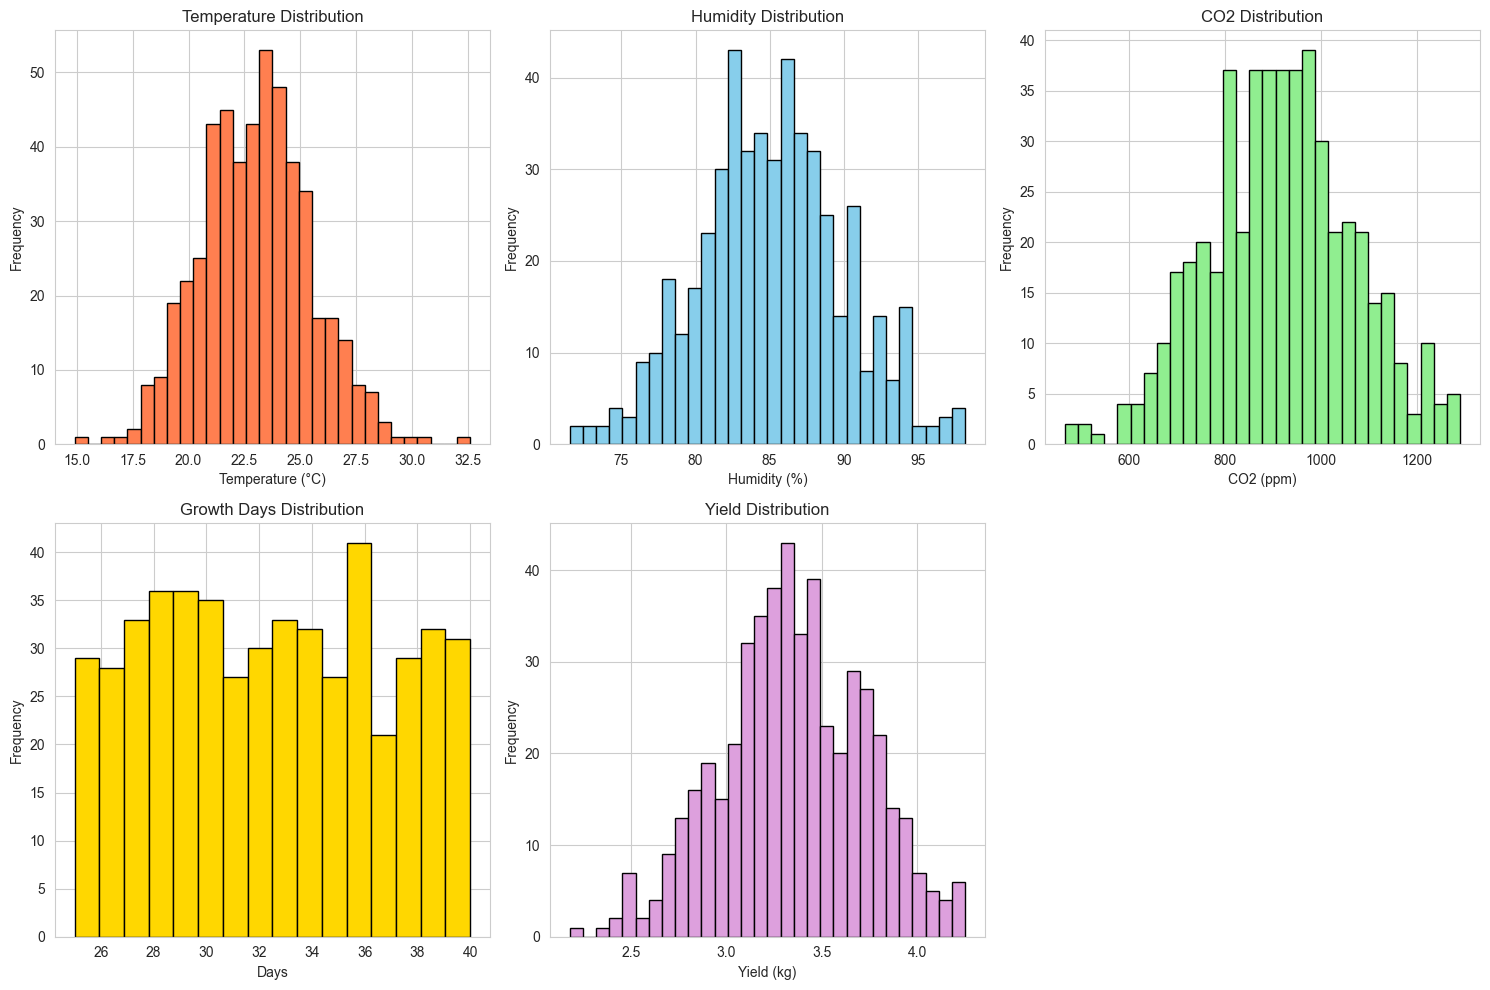

In [4]:
# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Temperature
axes[0, 0].hist(data['temperature'], bins=30, color='coral', edgecolor='black')
axes[0, 0].set_title('Temperature Distribution')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')

# Humidity
axes[0, 1].hist(data['humidity'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Humidity Distribution')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('Frequency')

# CO2
axes[0, 2].hist(data['co2_ppm'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('CO2 Distribution')
axes[0, 2].set_xlabel('CO2 (ppm)')
axes[0, 2].set_ylabel('Frequency')

# Growth Days
axes[1, 0].hist(data['growth_days'], bins=16, color='gold', edgecolor='black')
axes[1, 0].set_title('Growth Days Distribution')
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Frequency')

# Yield
axes[1, 1].hist(data['yield_kg'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Yield Distribution')
axes[1, 1].set_xlabel('Yield (kg)')
axes[1, 1].set_ylabel('Frequency')

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

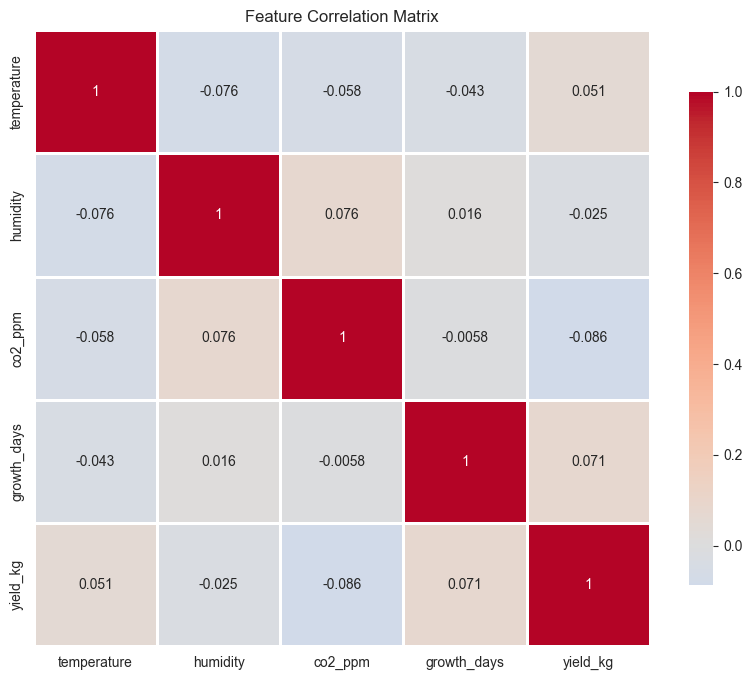


Correlation with Yield:
yield_kg       1.000000
growth_days    0.071497
temperature    0.051067
humidity      -0.024854
co2_ppm       -0.086007
Name: yield_kg, dtype: float64


In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.show()

print("\nCorrelation with Yield:")
print(correlation['yield_kg'].sort_values(ascending=False))

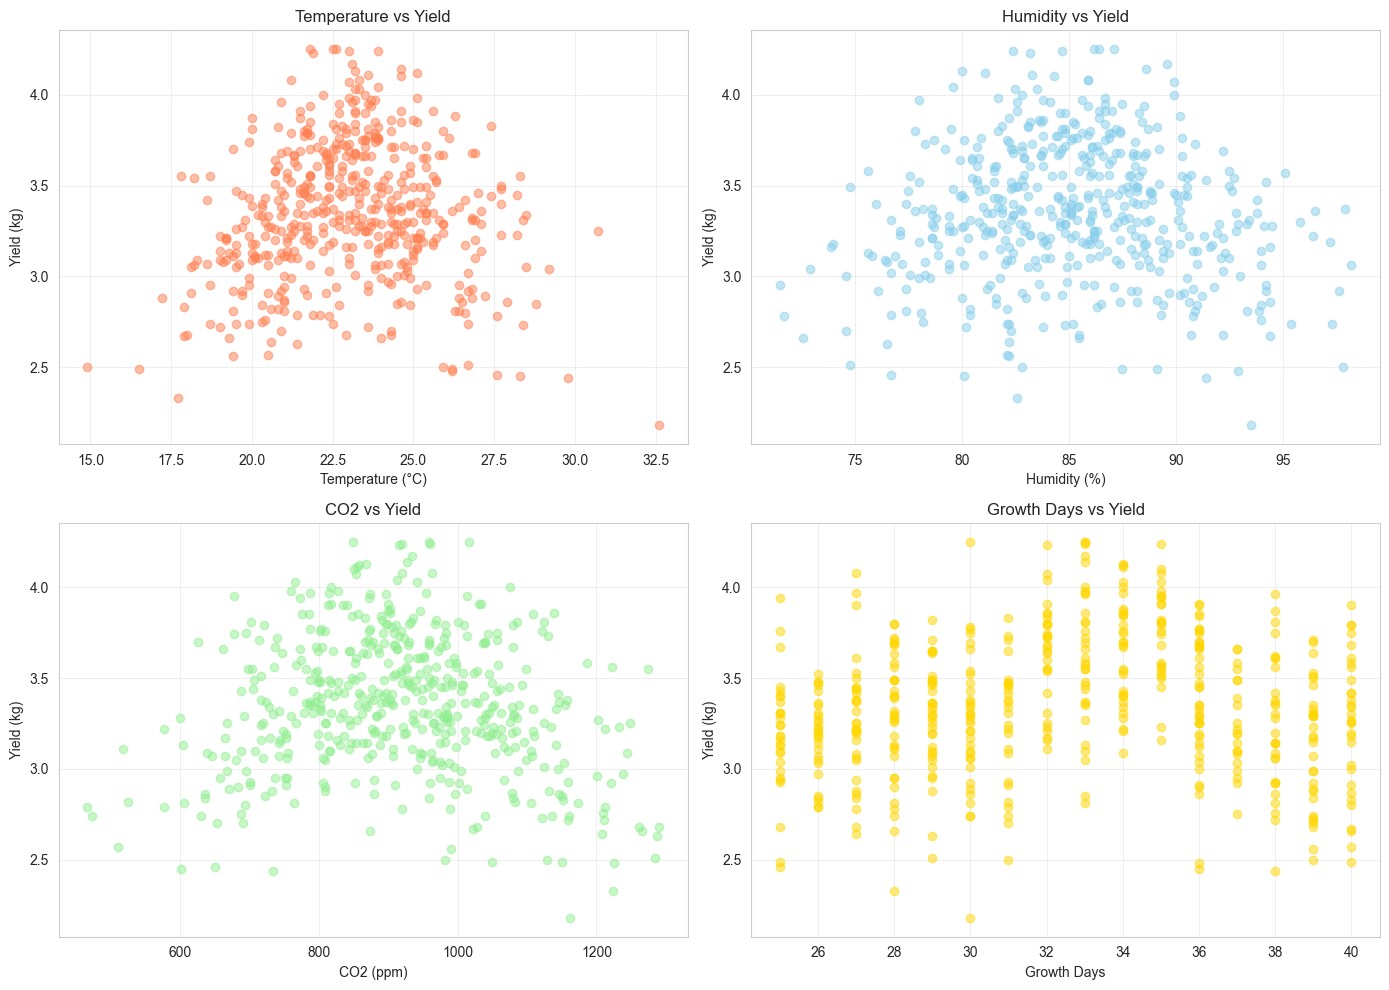

In [6]:
# Scatter plots: Features vs Yield
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature vs Yield
axes[0, 0].scatter(data['temperature'], data['yield_kg'], alpha=0.5, color='coral')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Yield (kg)')
axes[0, 0].set_title('Temperature vs Yield')
axes[0, 0].grid(True, alpha=0.3)

# Humidity vs Yield
axes[0, 1].scatter(data['humidity'], data['yield_kg'], alpha=0.5, color='skyblue')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('Yield (kg)')
axes[0, 1].set_title('Humidity vs Yield')
axes[0, 1].grid(True, alpha=0.3)

# CO2 vs Yield
axes[1, 0].scatter(data['co2_ppm'], data['yield_kg'], alpha=0.5, color='lightgreen')
axes[1, 0].set_xlabel('CO2 (ppm)')
axes[1, 0].set_ylabel('Yield (kg)')
axes[1, 0].set_title('CO2 vs Yield')
axes[1, 0].grid(True, alpha=0.3)

# Growth Days vs Yield
axes[1, 1].scatter(data['growth_days'], data['yield_kg'], alpha=0.5, color='gold')
axes[1, 1].set_xlabel('Growth Days')
axes[1, 1].set_ylabel('Yield (kg)')
axes[1, 1].set_title('Growth Days vs Yield')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Prepare Data for Training

In [7]:
# Separate features and target
X = data[['temperature', 'humidity', 'co2_ppm', 'growth_days']]
y = data['yield_kg']

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeature names: {list(X.columns)}")

Training samples: 400
Testing samples: 100

Feature names: ['temperature', 'humidity', 'co2_ppm', 'growth_days']


## 5. Train Machine Learning Models

### 5.1 Linear Regression Model

In [8]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lr:.4f} kg")
print(f"  Mean Absolute Error (MAE): {mae_lr:.4f} kg")
print(f"  R² Score: {r2_lr:.4f}")

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {lr_model.intercept_:.4f}")

Linear Regression Model Performance:
  Mean Squared Error (MSE): 0.1347
  Root Mean Squared Error (RMSE): 0.3670 kg
  Mean Absolute Error (MAE): 0.2930 kg
  R² Score: 0.0173

Model Coefficients:
  temperature: 0.0092
  humidity: 0.0001
  co2_ppm: -0.0001
  growth_days: 0.0061
  Intercept: 3.0698


### 5.2 Random Forest Regression Model

In [9]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.4f} kg")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f} kg")
print(f"  R² Score: {r2_rf:.4f}")

print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

Random Forest Model Performance:
  Mean Squared Error (MSE): 0.0607
  Root Mean Squared Error (RMSE): 0.2463 kg
  Mean Absolute Error (MAE): 0.1957 kg
  R² Score: 0.5572

Feature Importance:
       feature  importance
2      co2_ppm    0.321631
0  temperature    0.252068
3  growth_days    0.250325
1     humidity    0.175976


## 6. Visualize Model Performance

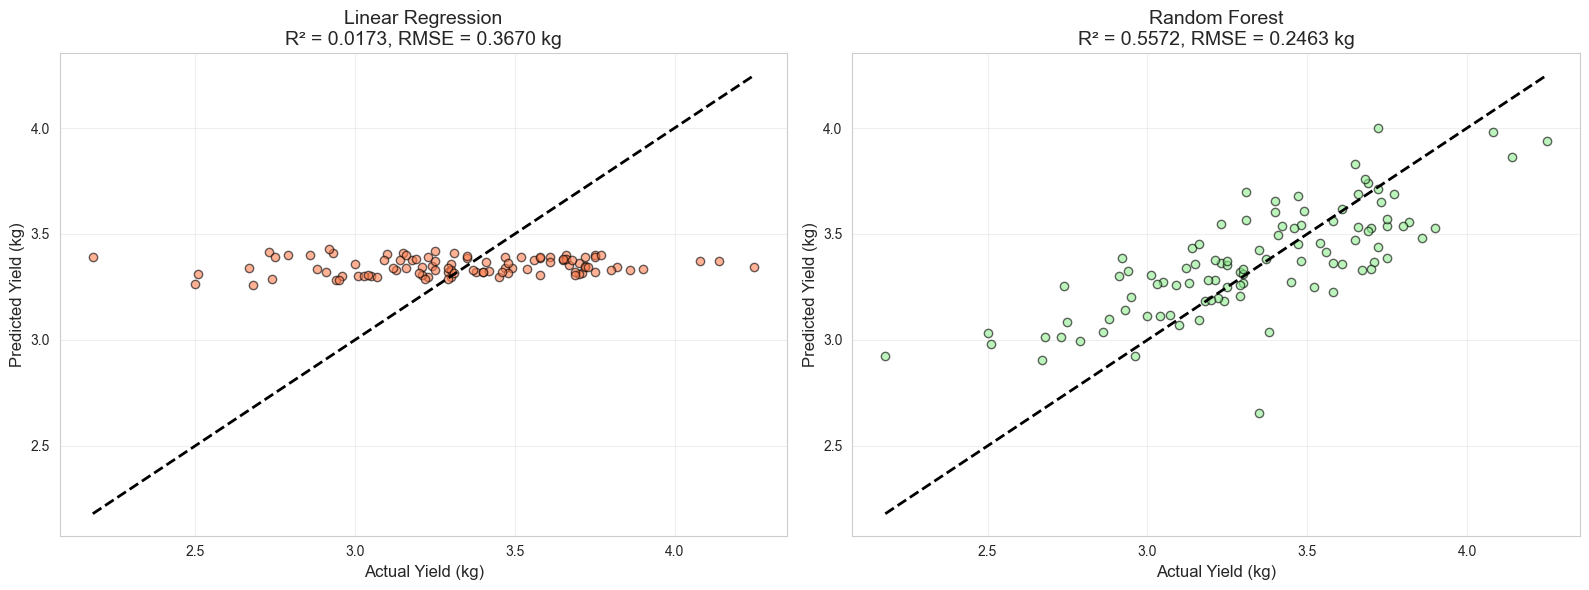

In [10]:
# Compare actual vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='coral', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_xlabel('Actual Yield (kg)', fontsize=12)
axes[0].set_ylabel('Predicted Yield (kg)', fontsize=12)
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.4f}, RMSE = {rmse_lr:.4f} kg', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='lightgreen', edgecolors='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_xlabel('Actual Yield (kg)', fontsize=12)
axes[1].set_ylabel('Predicted Yield (kg)', fontsize=12)
axes[1].set_title(f'Random Forest\nR² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f} kg', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

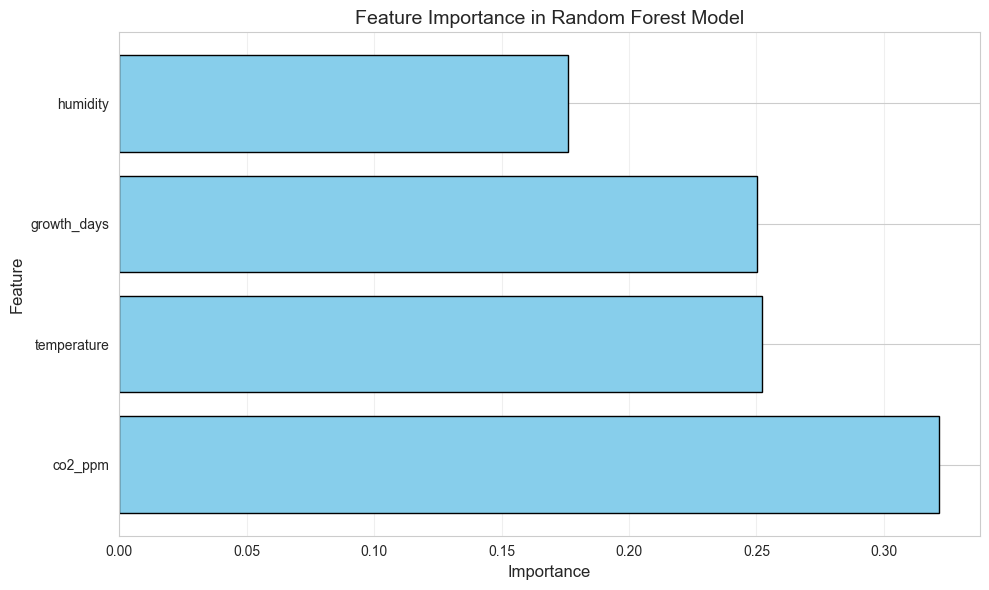

In [11]:
# Feature importance visualization for Random Forest
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Random Forest Model', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Make Predictions with New Data

In [12]:
# Example: Predict yield for optimal conditions
optimal_conditions = pd.DataFrame({
    'temperature': [23.0],
    'humidity': [85.0],
    'co2_ppm': [900],
    'growth_days': [33]
})

prediction_lr = lr_model.predict(optimal_conditions)
prediction_rf = rf_model.predict(optimal_conditions)

print("Predicted Yield for OPTIMAL Conditions:")
print(f"  Temperature: {optimal_conditions['temperature'][0]}°C")
print(f"  Humidity: {optimal_conditions['humidity'][0]}%")
print(f"  CO2: {optimal_conditions['co2_ppm'][0]} ppm")
print(f"  Growth Days: {optimal_conditions['growth_days'][0]}")
print(f"\n  Linear Regression Prediction: {prediction_lr[0]:.2f} kg")
print(f"  Random Forest Prediction: {prediction_rf[0]:.2f} kg")

Predicted Yield for OPTIMAL Conditions:
  Temperature: 23.0°C
  Humidity: 85.0%
  CO2: 900 ppm
  Growth Days: 33

  Linear Regression Prediction: 3.36 kg
  Random Forest Prediction: 4.00 kg


In [13]:
# Example: Predict yield for suboptimal conditions
suboptimal_conditions = pd.DataFrame({
    'temperature': [19.5],
    'humidity': [75.0],
    'co2_ppm': [1100],
    'growth_days': [28]
})

prediction_lr = lr_model.predict(suboptimal_conditions)
prediction_rf = rf_model.predict(suboptimal_conditions)

print("Predicted Yield for SUBOPTIMAL Conditions:")
print(f"  Temperature: {suboptimal_conditions['temperature'][0]}°C")
print(f"  Humidity: {suboptimal_conditions['humidity'][0]}%")
print(f"  CO2: {suboptimal_conditions['co2_ppm'][0]} ppm")
print(f"  Growth Days: {suboptimal_conditions['growth_days'][0]}")
print(f"\n  Linear Regression Prediction: {prediction_lr[0]:.2f} kg")
print(f"  Random Forest Prediction: {prediction_rf[0]:.2f} kg")

Predicted Yield for SUBOPTIMAL Conditions:
  Temperature: 19.5°C
  Humidity: 75.0%
  CO2: 1100 ppm
  Growth Days: 28

  Linear Regression Prediction: 3.27 kg
  Random Forest Prediction: 3.09 kg


## 8. Save the Model

In [14]:
# Save the Random Forest model (better performance)
model_filename = 'mushroom_yield_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Model saved as '{model_filename}'")
print("\nYou can load it later using:")
print("  with open('mushroom_yield_model.pkl', 'rb') as file:")
print("      model = pickle.load(file)")

Model saved as 'mushroom_yield_model.pkl'

You can load it later using:
  with open('mushroom_yield_model.pkl', 'rb') as file:
      model = pickle.load(file)


## 9. Integration Guide for Django App

To integrate this model into your Django mushroom dashboard:

1. **Save the model** (done above) in your Django project directory

2. **Create a prediction function** in `core/views.py`:
```python
import pickle
import pandas as pd
from django.conf import settings
import os

def predict_yield(temperature, humidity, co2, growth_days):
    model_path = os.path.join(settings.BASE_DIR, 'mushroom_yield_model.pkl')
    
    with open(model_path, 'rb') as file:
        model = pickle.load(file)
    
    input_data = pd.DataFrame({
        'temperature': [temperature],
        'humidity': [humidity],
        'co2_ppm': [co2],
        'growth_days': [growth_days]
    })
    
    prediction = model.predict(input_data)
    return round(prediction[0], 2)
```

3. **Use in production batches**: Add a `predicted_yield` field to calculate expected yield when starting a new batch

4. **Display predictions**: Show predicted vs actual yield in your dashboard analytics